In [ ]:
# # HFSS to SBR+ time animation
#
# This example shows how to use PyAEDT to create an SBR+ time animation
# and save it to a GIF file. This example works only on CPython.
#
# Keywords: **HFSS**, **SBR+**, **time domain**, **IFFT**.

# ## Perform imports and define constants
#
# Perform required imports.

# +
import os
import tempfile
import time

from ansys.aedt.core import Hfss
from ansys.aedt.core.examples.downloads import download_sbr_time
# -


In [ ]:

# Define constants.

AEDT_VERSION = "2025.2"
NUM_CORES = 4
NG_MODE = False  # Open AEDT UI when it is launched.


# ## Create temporary directory
#
# Create a temporary directory where downloaded data or
# dumped data can be stored.
# If you'd like to retrieve the project data for subsequent use,
# the temporary folder name is given by ``temp_folder.name``.

temp_folder = tempfile.TemporaryDirectory(suffix=".ansys")


# ## Download project

project_file = download_sbr_time(local_path=temp_folder.name)

# ## Launch HFSS and analyze

hfss = Hfss(
    project=project_file,
    version=AEDT_VERSION,
    non_graphical=NG_MODE,
    new_desktop=True,
)


In [ ]:

hfss.analyze(cores=NUM_CORES)

# ## Get solution data
#
# Get solution data. After the simulation is performed, you can load solutions
# in the ``solution_data`` object.

solution_data = hfss.post.get_solution_data(
    expressions=["NearEX", "NearEY", "NearEZ"],
    variations={"_u": ["All"], "_v": ["All"], "Freq": ["All"]},
    context="Near_Field",
    report_category="Near Fields",
)

# ## Compute IFFT
#
# Compute IFFT (Inverse Fast Fourier Transform).

t_matrix = solution_data.ifft("NearE", window=True)

# ## Export IFFT to CSV file
#
# Export IFFT to a CSV file.

frames_list_file = solution_data.ifft_to_file(
    coord_system_center=[-0.15, 0, 0],
    db_val=True,
    csv_path=os.path.join(hfss.working_directory, "csv"),
)

# ## Plot scene
#
# Plot the scene to create the time plot animation

hfss.post.plot_scene(
    frames=frames_list_file,
    gif_path=os.path.join(hfss.working_directory, "animation.gif"),
    norm_index=15,
    dy_rng=35,
    show=False,
    view="xy",
    zoom=1,
)

# ## Release AEDT
#
# Release AEDT and close the example.

hfss.save_project()
hfss.release_desktop()
# Wait 3 seconds to allow AEDT to shut down before cleaning the temporary directory.
time.sleep(3)

# ## Clean up
#
# All project files are saved in the folder ``temp_folder.name``. If you've run this example as a Jupyter notebook, you
# can retrieve those project files. The following cell removes all temporary files, including the project folder.

temp_folder.cleanup()


                                             Project  Impact  Feasibility  \
0                     Drone Digital Twin Motor Model       5            4   
1            Generative AI Humanoid Robot Simulation       5            2   
2     Reinforcement Learning for Wireless Simulation       3            3   
3                      Exoskeleton Power Unit Design       4            2   
4  Physics-Informed Neural Networks (PINN) for Si...       4            3   
5                      Traction Motor Cooling Design       4            4   
6              Motor Simulation & Optimization Tools       4            4   
7      Battery Electric Vehicle Model & Optimization       4            4   
8                 Drone Supply Chain & Manufacturing       5            2   
9                           AI Drone Swarm & Defense       5            2   

                              Rationale  
0               디지털 트윈을 활용한 드론 모터 모형 구현  
1            생성형 AI를 활용한 휴머노이드 로봇 시뮬레이션  
2              강화학습을 적용한 무

c:\Users\HAN_NDESKTOP\.ansys_python_venvs\pyAEDT_conda\Lib\site-packages\adjustText\__init__.py:419: UserWarning: Glyph 45230 (\N{HANGUL SYLLABLE NAJ}) missing from font(s) DejaVu Sans.
  ax.figure.draw_without_rendering()
c:\Users\HAN_NDESKTOP\.ansys_python_venvs\pyAEDT_conda\Lib\site-packages\adjustText\__init__.py:419: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  ax.figure.draw_without_rendering()
c:\Users\HAN_NDESKTOP\.ansys_python_venvs\pyAEDT_conda\Lib\site-packages\adjustText\__init__.py:419: UserWarning: Glyph 45458 (\N{HANGUL SYLLABLE NOP}) missing from font(s) DejaVu Sans.
  ax.figure.draw_without_rendering()
Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.
C:\Users\HAN_NDESKTOP\AppData\Local\Temp\ipykernel_22712\1474680759.py:111: UserWarning: Glyph 45230 (\N{HANGUL SYLLABLE NAJ}) missing from font(s

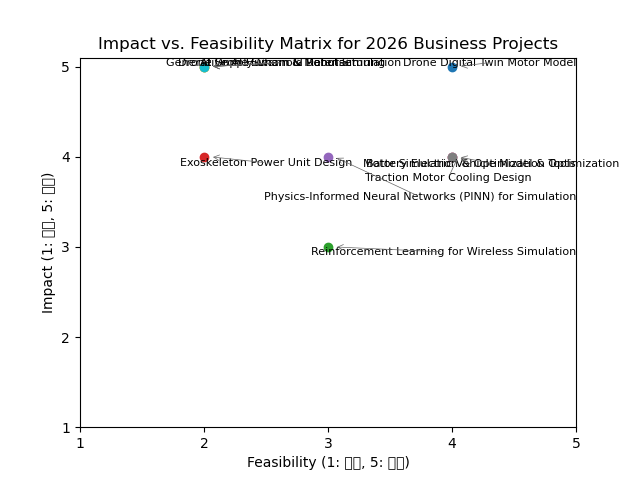

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text

# 한글 폰트 설정 (Windows 기본: Malgun Gothic; 대체 폰트 순서 포함)
plt.rcParams['font.family'] = [
    'Malgun Gothic',            # Windows
    'NanumGothic',              # Linux
    'Noto Sans CJK KR',         # Cross-platform
    'Apple SD Gothic Neo',      # macOS
    'Segoe UI', 'Arial Unicode MS'
]
plt.rcParams['axes.unicode_minus'] = False  # 한글 사용 시 마이너스 깨짐 방지

# 1. 내년도 사업 후보 목록 정의
tasks = [
    {
        'Project': 'Drone Digital Twin Motor Model',
        'Impact': 5,
        'Feasibility': 4,
        'Rationale': '디지털 트윈을 활용한 드론 모터 모형 구현'
    },
    {
        'Project': 'Generative AI Humanoid Robot Simulation',
        'Impact': 5,
        'Feasibility': 2,
        'Rationale': '생성형 AI를 활용한 휴머노이드 로봇 시뮬레이션'
    },
    {
        'Project': 'Reinforcement Learning for Wireless Simulation',
        'Impact': 3,
        'Feasibility': 3,
        'Rationale': '강화학습을 적용한 무선 전파 환경 시뮬레이션'
    },
    {
        'Project': 'Exoskeleton Power Unit Design',
        'Impact': 4,
        'Feasibility': 2,
        'Rationale': '외골격 로봇 파워 유닛 설계 및 최적화'
    },
    {
        'Project': 'Physics-Informed Neural Networks (PINN) for Simulation',
        'Impact': 4,
        'Feasibility': 3,
        'Rationale': '물리 기반 인공신경망을 활용한 모델링'
    },
    {
        'Project': 'Traction Motor Cooling Design',
        'Impact': 4,
        'Feasibility': 4,
        'Rationale': '전기차 구동용 모터 냉각 방식 개발'
    },
    {
        'Project': 'Motor Simulation & Optimization Tools',
        'Impact': 4,
        'Feasibility': 4,
        'Rationale': 'MotorCAD/JMAG을 이용한 시뮬레이션 및 최적화 도구 개발'
    },
    {
        'Project': 'Battery Electric Vehicle Model & Optimization',
        'Impact': 4,
        'Feasibility': 4,
        'Rationale': 'Simscape 기반 배터리 전기차 모델과 파라미터 최적화'
    },
    {
        'Project': 'Drone Supply Chain & Manufacturing',
        'Impact': 5,
        'Feasibility': 2,
        'Rationale': '드론 공급망 및 대량생산 전략'
    },
    {
        'Project': 'AI Drone Swarm & Defense',
        'Impact': 5,
        'Feasibility': 2,
        'Rationale': 'AI 기반 드론 군집과 국방 응용'
    }
]

# 2. 데이터프레임 생성
df = pd.DataFrame(tasks)

# 필요하다면 데이터프레임 확인
print(df)

# 3. Impact–Feasibility 산점도 그리기
fig, ax = plt.subplots()

xs, ys, texts = [], [], []
for task in tasks:
    x = task['Feasibility']
    y = task['Impact']
    xs.append(x)
    ys.append(y)

    # 산점도 점 찍기
    ax.scatter(x, y)

    # 각 점에 프로젝트명 라벨링 (일단 근처에 배치)
    t = ax.text(x + 0.05, y, task['Project'], fontsize=8)
    texts.append(t)

# 축 레이블 및 제목 설정
ax.set_xlabel('Feasibility (1: 낮음, 5: 높음)')
ax.set_ylabel('Impact (1: 낮음, 5: 높음)')
ax.set_title('Impact vs. Feasibility Matrix for 2026 Business Projects')
ax.set_xticks(range(1, 6))
ax.set_yticks(range(1, 6))

# 3.5 라벨 겹침 자동 조정 (adjustText)
adjust_text(
    texts, x=xs, y=ys, ax=ax,
    arrowprops=dict(arrowstyle='->', color='0.4', lw=0.5),
    expand_text=(1.2, 1.2),
    expand_points=(1.2, 1.2),
    force_points=0.1,
    force_text=0.3,
    lim=100,
)

# 4. 그래프 저장 (옵션)
plt.savefig('impact_feasibility_matrix.png', bbox_inches='tight')
plt.show()


In [ ]:
import plotly.express as px

# Plotly 인터랙티브 산점도 (라벨 겹침 방지: hover 중심)
fig = px.scatter(
    df,
    x="Feasibility",
    y="Impact",
    text="Project",  # 고정 라벨 표시. 겹침이 거슬리면 아래에서 None으로 전환
    hover_data={
        "Project": True,
        "Feasibility": True,
        "Impact": True,
        "Rationale": True,
    },
    range_x=[0.5, 5.5],
    range_y=[0.5, 5.5],
    title="Impact vs. Feasibility Matrix (Interactive)",
)

# 스타일 조정
fig.update_traces(
    textposition="top center",  # 'markers+text' 효과. 겹침 시 아래의 hover-only 모드 사용 권장
    marker=dict(size=10, color="royalblue"),
    textfont=dict(family="Malgun Gothic, Nanum Gothic, Noto Sans CJK KR, Apple SD Gothic Neo, Segoe UI, Arial Unicode MS")
)
fig.update_layout(
    xaxis_title="Feasibility (1: 낮음, 5: 높음)",
    yaxis_title="Impact (1: 낮음, 5: 높음)",
    xaxis=dict(dtick=1, zeroline=False),
    yaxis=dict(dtick=1, zeroline=False),
    template="plotly_white",
    margin=dict(l=40, r=20, t=60, b=40),
    font=dict(family="Malgun Gothic, Nanum Gothic, Noto Sans CJK KR, Apple SD Gothic Neo, Segoe UI, Arial Unicode MS", size=12)
)

# 라벨 겹침이 신경 쓰이면 hover만 사용하기 (권장):
# fig.update_traces(text=None)

fig.show()

# HTML로 저장 (정적 PNG 저장은 kaleido 필요. HTML은 바로 저장 가능)
fig.write_html("impact_feasibility_matrix_interactive.html", include_plotlyjs="cdn")


findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Apple SD Gothic Neo' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font fa

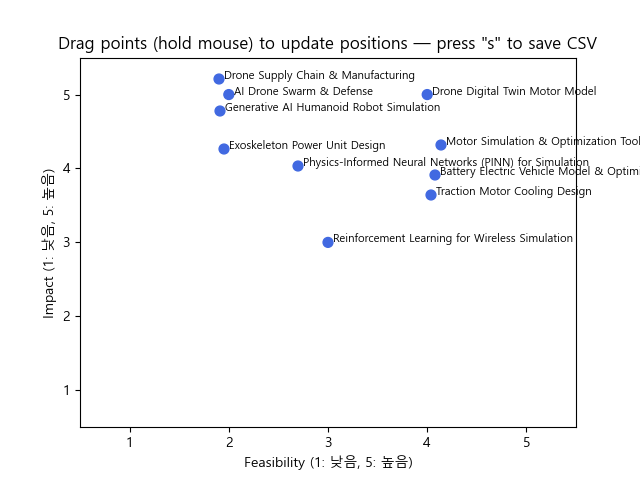

In [7]:
%matplotlib widget
# Matplotlib: 마우스로 점을 드래그해 이동하고 DataFrame 업데이트하기
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from adjustText import adjust_text  

# 한글 폰트 설정 (Windows 기본: Malgun Gothic; 대체 폰트 순서 포함)
plt.rcParams['font.family'] = [
    'Malgun Gothic',            # Windows
    'NanumGothic',              # Linux
    'Noto Sans CJK KR',         # Cross-platform
    'Apple SD Gothic Neo',      # macOS
    'Segoe UI', 'Arial Unicode MS'
]
plt.rcParams['axes.unicode_minus'] = False

# 기존 df를 사용합니다: df['Feasibility'], df['Impact'], df['Project']
xs = df["Feasibility"].astype(float).to_numpy()
ys = df["Impact"].astype(float).to_numpy()
labels = df["Project"].astype(str).to_list()

fig, ax = plt.subplots()
sizes = np.full(len(xs), 50.0)
sc = ax.scatter(xs, ys, s=sizes, color="royalblue")
texts = [ax.text(xs[i] + 0.05, ys[i], labels[i], fontsize=8) for i in range(len(xs))]

ax.set_xlim(0.5, 5.5)
ax.set_ylim(0.5, 5.5)
ax.set_xlabel('Feasibility (1: 낮음, 5: 높음)')
ax.set_ylabel('Impact (1: 낮음, 5: 높음)')
ax.set_title('Drag points (hold mouse) to update positions — press "s" to save CSV')
ax.set_xticks(range(1, 6))
ax.set_yticks(range(1, 6))

selected = {"ind": None}
threshold2 = 0.15 ** 2  # 선택 허용 반경^2 (데이터 좌표계)

def nearest_index(x, y):
    d2 = (xs - x) ** 2 + (ys - y) ** 2
    i = int(np.argmin(d2))
    return i, float(d2[i])

def on_press(event):
    if event.inaxes != ax or event.xdata is None or event.ydata is None:
        return
    i, d2 = nearest_index(event.xdata, event.ydata)
    if d2 <= threshold2:
        selected["ind"] = i
        sizes[i] = 120.0
        sc.set_sizes(sizes)
        fig.canvas.draw_idle()

def on_motion(event):
    i = selected.get("ind", None)
    if i is None or event.inaxes != ax or event.xdata is None or event.ydata is None:
        return
    # 좌표 업데이트
    xs[i] = float(event.xdata)
    ys[i] = float(event.ydata)
    sc.set_offsets(np.c_[xs, ys])
    texts[i].set_position((xs[i] + 0.05, ys[i]))
    fig.canvas.draw_idle()

def on_release(event):
    i = selected.get("ind", None)
    if i is None:
        return
    sizes[i] = 50.0
    sc.set_sizes(sizes)
    # DataFrame에 반영
    df.loc[i, 'Feasibility'] = xs[i]
    df.loc[i, 'Impact'] = ys[i]
    print(f"Updated: {labels[i]} -> Feasibility={xs[i]:.2f}, Impact={ys[i]:.2f}")
    selected["ind"] = None
    fig.canvas.draw_idle()

def on_key(event):
    if event.key == 's':
        out = 'impact_feasibility_matrix_updated.csv'
        df.to_csv(out, index=False)
        print(f"Saved updated DataFrame to {out}")

fig.canvas.mpl_connect('button_press_event', on_press)
fig.canvas.mpl_connect('motion_notify_event', on_motion)
fig.canvas.mpl_connect('button_release_event', on_release)
fig.canvas.mpl_connect('key_press_event', on_key)

plt.show()


In [8]:
import os
import pyvista as pv
import pyacvd
import pyansys

ModuleNotFoundError: No module named 'pyacvd'

In [9]:
import gmsh
import math
import os

gmsh.initialize()
gmsh.option.setNumber("General.Terminal", 1)


In [12]:

gmsh.model.add("t20")


In [27]:

# Load a STEP file (using `importShapes' instead of `merge' allows to directly
# retrieve the tags of the highest dimensional imported entities):
# path = os.path.dirname(os.path.abspath(__file__))
# filename = r'\\192.168.0.165\디지털융합사업본부\01_EM사업부\0_인수인계\송인수\[1]project\[3]DOOWON_Compressor_BLDC\[5]Final_Modified_STP_for_NVH_Solution\0.SG2EV_Rotor-Magnet.stp'
# filename=r"D:\KDH\Drone\MOA_Drone.stp"
# filename=r"D:\KDH\Drone\Drone_1.stp"
filename=r'\\192.168.0.165\디지털융합사업본부\01_EM사업부\정희철\01_프로젝트\2023_LIG넥스원_200k_수송드론\LIG_Nex1_Drone\LIG_Nex1_Drone_final.stp'
v = gmsh.model.occ.importShapes(filename)

In [28]:

# Get the bounding box of the volume:
gmsh.model.occ.synchronize()

# Specify a global mesh size and mesh the partitioned model:
gmsh.option.setNumber("Mesh.CharacteristicLengthMin", 10)
gmsh.option.setNumber("Mesh.CharacteristicLengthMax", 10)
gmsh.model.mesh.generate(3)
gmsh.write("from_gmsh.msh")

In [29]:
gmsh.fltk.run()
